In [1]:
import monai

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [7]:
hr_mag = "../data/nifti_patients/001_20240313_7T/Magnitude_NoProto_WIP_fl3d1r3.nii.gz"
lr_mag = "../data/nifti_patients/001_20240313_3T/Magnitude_NoProto_WIP_pc3d1r3.nii.gz"

# Corrección Fundamental: Indicar que la dimensión Tiempo (la última, -1) es el Canal.
# De lo contrario, Monai toma la dimensión de Slices como canal y no la resamplea.
transform = monai.transforms.Compose([
    monai.transforms.LoadImaged(keys=["hr", "lr"]),
    monai.transforms.EnsureChannelFirstd(keys=["hr", "lr"], channel_dim=-1), # (H,W,D,T) -> (T, H,W,D)
    monai.transforms.ResampleToMatchd(keys=["lr"], key_dst="hr"),
])

# Importante: Vuelve a ejecutar esta celda para regenerar 'data' con el shape correcto
print("Ejecutando pipeline de MONAI (Load -> ChannelFirst -> Resample)...")
data = transform({"hr": hr_mag, "lr": lr_mag})
print("Pipeline completado.")

Ejecutando pipeline de MONAI (Load -> ChannelFirst -> Resample)...
Pipeline completado.


In [8]:
data["hr"].shape, data["lr"].shape

(torch.Size([28, 448, 448, 48]), torch.Size([9, 448, 448, 48]))

Shape HR (Numpy): (448, 448, 48)
Shape LR Resampled (Numpy): (448, 448, 48)


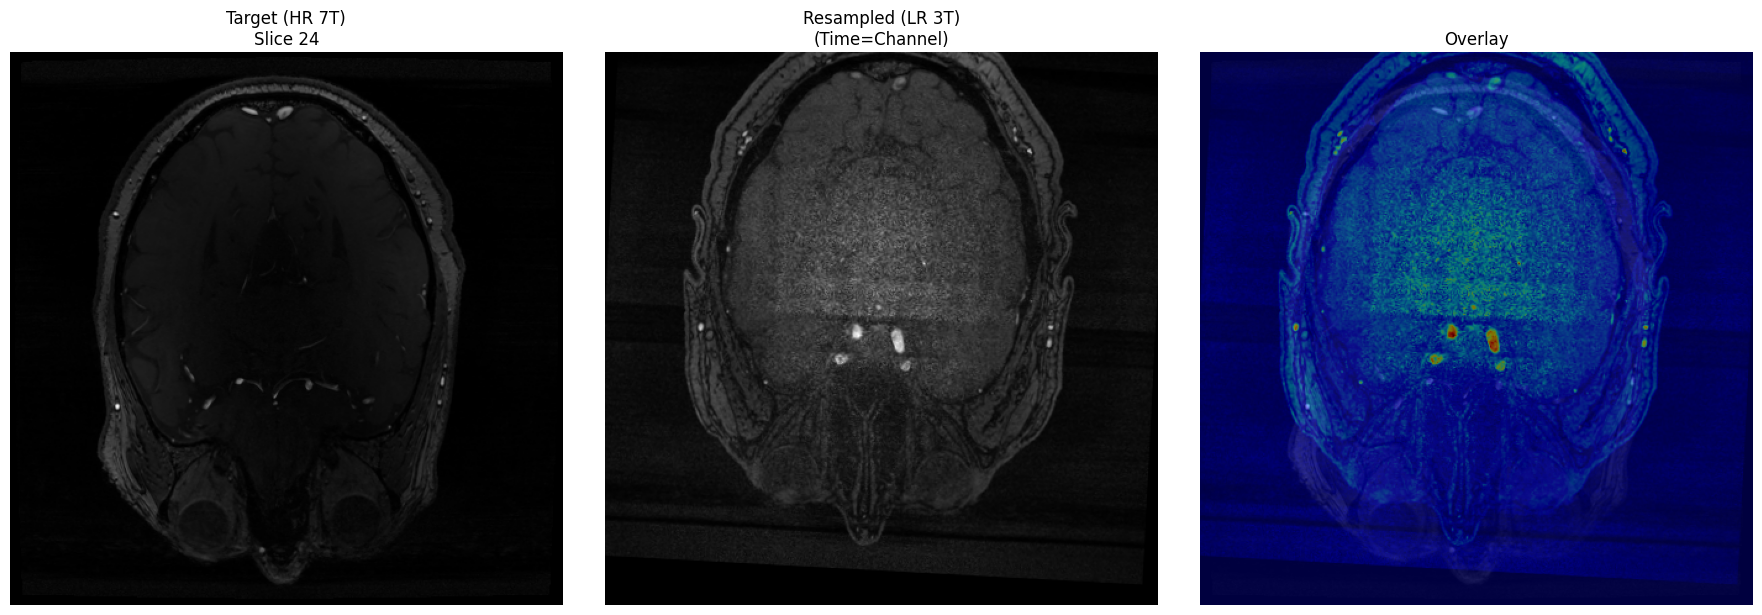

--- Métricas de Similitud ---
MSE: 0.00868
MAE: 0.06724
Correlación: 0.35163


In [9]:
import matplotlib.pyplot as plt
import numpy as np

# --- Helper functions ---
def to_numpy_3d(img_tensor):
    """Convierte tensor Monai (C, H, W, D) a numpy 3D (H,W,D) tomando el primer canal."""
    arr = img_tensor.cpu().numpy() if hasattr(img_tensor, "cpu") else img_tensor
    
    # Monai (EnsureChannelFirstd channel_dim=-1) nos da: (Time, H, W, D)
    # Por ejemplo: (48, 448, 448, 28)
    if arr.ndim == 4:
        # Tomamos el primer timepoint (t=0)
        return arr[0, ...] 
        
    return arr

# --- 1. Preparar Datos ---
# Asegúrate de haber ejecutado la celda anterior modificada
vol_hr = to_numpy_3d(data["hr"])
vol_lr = to_numpy_3d(data["lr"])

def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)

print(f"Shape HR (Numpy): {vol_hr.shape}")
print(f"Shape LR Resampled (Numpy): {vol_lr.shape}")

if vol_hr.shape != vol_lr.shape:
    print("⚠ ¡ALERTA! Las dimensiones siguen siendo distintas. Verifica 'channel_dim=-1' en la celda anterior.")
else:
    # --- 2. Visualización ---
    z_idx = vol_hr.shape[2] // 2 # Z es la última dim ahora (H, W, D)

    slice_hr = vol_hr[:, :, z_idx].T
    slice_lr = vol_lr[:, :, z_idx].T

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(slice_hr, cmap="gray", origin="lower")
    axes[0].set_title(f"Target (HR 7T)\nSlice {z_idx}")
    axes[0].axis('off')

    axes[1].imshow(slice_lr, cmap="gray", origin="lower")
    axes[1].set_title(f"Resampled (LR 3T)\n(Time=Channel)")
    axes[1].axis('off')

    # Overlay
    axes[2].imshow(slice_hr, cmap="gray", origin="lower")
    axes[2].imshow(slice_lr, cmap="jet", origin="lower", alpha=0.5)
    axes[2].set_title("Overlay")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    # --- 3. Métricas ---
    n_hr = normalize(vol_hr)
    n_lr = normalize(vol_lr)

    mse = np.mean((n_hr - n_lr) ** 2)
    mae = np.mean(np.abs(n_hr - n_lr))
    corr = np.corrcoef(n_hr.flatten(), n_lr.flatten())[0, 1]

    print("--- Métricas de Similitud ---")
    print(f"MSE: {mse:.5f}")
    print(f"MAE: {mae:.5f}")
    print(f"Correlación: {corr:.5f}")